## Summary of key insights

- Most features are categorical (all but price and sale date), many of them take a huge number of different values, many values appearing only once, which will make prediction difficult without some pooling

- The price distribution is very right skewed, so much so that I had to cap the price at say 30k to make graphics legible.

- Almost all sales were done after 1985. A very strong inflation is visible over time since 1985, stronger than general consumer index inflation. Perhaps a feature "inflation corrected price" is needed.

- Cellos are the most valued, followed by violins and viols and bows. Several instrument types are very rare.

- The 40 distinct auction_houses achieve remarkably different distribution prices. So do the 30 most frequent makers. French makers and auction_houses are particulary represented among the most expensive sales. A nationality feature could be interesting, though there is already a city (of sale, and of maker) feature that might do the trick.

- In general, the more ancient the instrument, the more valuable. Yet 1500 makers lack the date, representing 6k sales, which is a significant caveat. Ideally, we could write some script to fetch their date from some other database on internet.

## Importation of packages and data frames

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
sales=pd.read_csv("cozio_sales_ALL.csv")

In [9]:
sales.isna().sum()

maker_id             0
maker_name           0
type                 0
city_maker       17960
auction_house     4401
sale_date            0
lot               4401
usd                  4
gbp                  4
eur              22368
bold_currency     4050
dtype: int64

There are 11 columns ; maker_id and maker_name are probably the same thing, they identify a maker. The bold currency (usd, gbp or eur) indicates in which currency the sale was made. It is often missing. We can see a probable duplicate here, sales 57165 and 57165 - one simply has a feature lot missing, under the form -, as well the city_maker. We'll have to look into that.

In [ ]:
sales[sales.duplicated()]
#there are no exact duplicates

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency


In [15]:
sales[sales.duplicated(['maker_id','type','sale_date','usd'],keep=False)]

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
52,1988,"Adam, Jean 'Grand'",Violin Bow,Mirecourt,Sotheby's,"Oct 5, 2010",-,27851.0,17500.0,20211.0,gbp
53,1988,"Adam, Jean 'Grand'",Violin Bow,NaN,Sotheby's,"Oct 5, 2010",118,27851.0,17500.0,20211.0,NaN
95,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255A,8865.0,5980.0,NaN,NaN
96,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255AA,8865.0,5980.0,NaN,NaN
176,15601,"Aguzzi, Dario",Violin,Pavia,Brompton's,"Jun 7, 2021",184,2834.0,2000.0,2330.0,gbp
...,...,...,...,...,...,...,...,...,...,...,...
57069,1193,"Zanoli, Giacomo",Violin,NaN,Butterfield & Butterfield,"Oct 18, 1999",8046,28750.0,17195.0,26454.0,usd
57075,1680,"Zanotti, Antonio",Violin,Mantua,Sotheby's,"Nov 7, 2006",-,80212.0,42000.0,62887.0,gbp
57076,1680,"Zanotti, Antonio",Violin,NaN,Sotheby's,"Nov 7, 2006",139,80212.0,42000.0,62887.0,gbp
57165,844,"Zygmuntowicz, Samuel",Violin,"New York, NY",Brompton's,"Dec 14, 2009",-,15634.0,9600.0,10674.0,gbp


We do seem to see 3 pairs of duplicates here, but the rows with lots 255A and 255AA are probably genuinely different (a sublot in the world of auction house). We'll look for sales which in only differ in the lot being "-" instead of a proper values and consider them duplicates.

In [70]:
cols = ['sale_date', 'maker_id', 'type', 'usd', 'gbp', 'auction_house']
mask_dash = sales['lot'] == '-'
has_twin = sales[mask_dash].apply(
    lambda r: ((sales[cols] == r[cols]).all(axis=1) & (sales['lot'] != '-')).any(),
    axis=1
)
sales = sales.drop(index=sales[mask_dash][has_twin].index)

In [71]:
len(sales)
# we lost 188 rows, kind of negligible

56981

In [22]:
sales[sales.duplicated(['maker_id','type','sale_date','usd'],keep=False)]

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
95,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255A,8865.0,5980.0,NaN,NaN
96,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255AA,8865.0,5980.0,NaN,NaN
176,15601,"Aguzzi, Dario",Violin,Pavia,Brompton's,"Jun 7, 2021",184,2834.0,2000.0,2330.0,gbp
177,15601,"Aguzzi, Dario",Violin,Pavia,Brompton's,"Jun 7, 2021",199,2834.0,2000.0,2330.0,gbp
526,8,"Amati, Antonio & Girolamo",Violin,Cremona,Phillip's,"Nov 15, 1990",176,49575.0,25300.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
56568,1176,"Withers, George Thomas Henry",Violin Bow,London,Sotheby's,"Sep 16, 1987",145,543.0,330.0,NaN,gbp
56589,971,"Wolff, Brothers",Violin,NaN,Bonhams,"Mar 11, 2009",60,1488.0,1080.0,1164.0,gbp
56590,971,"Wolff, Brothers",Violin,NaN,Bonhams,"Mar 11, 2009",61,1488.0,1080.0,1164.0,gbp
56603,971,"Wolff, Brothers",Violin,Kreuznach,Phillip's,"Jun 18, 2001",250,702.0,500.0,818.0,gbp


These are clearly not duplicates, but let's check if maybe some are duplicates up to NAs.

In [60]:
keys = ['maker_id','type','sale_date','usd','auction_house']


sales = sales.sort_values(by=cols)


sales[sales['lot'].isna() & sales.duplicated(cles_identification,keep=False)]
# they seem to be duplicates, with the pattern city missing vs city filled as above. we'll delete them and will be done deduplicating.

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
32159,1309,"Martin, Jean-Joseph",Violin Bow,Paris,NaN,2024-03-22,NaN,4236.0,3360.0,3916.0,gbp
32160,1309,"Martin, Jean-Joseph",Violin Bow,NaN,NaN,2024-03-22,NaN,4236.0,3360.0,3916.0,gbp
44154,647,"Sartory, Eugène Nicolas",Violin Bow,Paris,NaN,2025-10-28,NaN,30270.0,22800.0,26027.0,gbp
44161,647,"Sartory, Eugène Nicolas",Violin Bow,NaN,NaN,2025-10-28,NaN,30270.0,22800.0,26027.0,gbp


In [66]:
sales[sales['lot'].isna() & sales.duplicated(cles_identification,keep='first')]

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
32160,1309,"Martin, Jean-Joseph",Violin Bow,NaN,NaN,"Mar 22, 2024",NaN,4236.0,3360.0,3916.0,gbp
44161,647,"Sartory, Eugène Nicolas",Violin Bow,NaN,NaN,"Oct 28, 2025",NaN,30270.0,22800.0,26027.0,gbp


In [77]:
sales=sales[~(sales['lot'].isna() & sales.duplicated(cles_identification,keep='first'))]
sales['sale_date']=pd.to_datetime(sales.sale_date)
sales.to_csv('sales_dedup.csv',index=False)

In [78]:
sales

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
0,2919,"Achner, Michael",Violin,Wallgau,Tarisio,2010-02-20,354,4200.0,2721.0,3107.0,usd
1,2919,"Achner, Michael",Violin,Mittenwald,Bongartz's,1987-04-27,145,2838.0,1702.0,NaN,NaN
2,2611,"Achner, Philip",Violin,Mittenwald,Tarisio,2018-05-17,123,24000.0,17759.0,20330.0,usd
3,2611,"Achner, Philip",Violin,NaN,Bongartz's,2008-11-15,138,3884.0,2613.0,3064.0,NaN
4,2611,"Achner, Philip",Violin,Mittenwald,Sotheby's,1990-03-27,16,2146.0,1320.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
57163,844,"Zygmuntowicz, Samuel",Cello,"Brooklyn, NY",Tarisio,2012-04-27,76,84000.0,51769.0,63497.0,usd
57164,844,"Zygmuntowicz, Samuel",Violin,"Brooklyn, NY",Tarisio,2012-04-27,311,108000.0,66560.0,81639.0,usd
57166,844,"Zygmuntowicz, Samuel",Violin,NaN,Brompton's,2009-12-14,1,15634.0,9600.0,10674.0,gbp
57167,844,"Zygmuntowicz, Samuel",Violin,"Brooklyn, NY",Tarisio,2003-05-08,144,130000.0,81078.0,113686.0,usd


In [82]:
sales=sales.sort_values(by='sale_date')
sales
# data range from 1829 to basically the day we scraped the web archive

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
43794,636,"Rugeri, Francesco",Cello,Cremona,Sotheby's,1829-05-03,-,357.0,70.0,NaN,gbp
43083,623,"Rogeri, Giovanni Battista",Cello,Brescia,Puttick & Simpson,1850-11-28,-,368.0,72.0,NaN,gbp
48189,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,588.0,115.0,NaN,gbp
48190,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,715.0,140.0,NaN,gbp
48188,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1853-05-28,-,606.0,110.0,NaN,gbp
...,...,...,...,...,...,...,...,...,...,...,...
4502,64,"Bernardel, Léon",Violin,Paris,NaN,2025-11-21,NaN,2350.0,1796.0,2040.0,eur
21491,7609,"Hendel, Arno Erwin",Violin,NaN,NaN,2025-11-21,NaN,2405.0,1838.0,2088.0,eur
41556,1213,"Prager, Gustav Adolf",Violin Bow,NaN,NaN,2025-11-21,NaN,755.0,577.0,655.0,eur
4402,63,"Bernardel, Gustave Adolphe",Violin,Paris,NaN,2025-12-05,NaN,4800.0,3597.0,4122.0,usd


In [8]:
import matplotlib.pyplot as plt

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

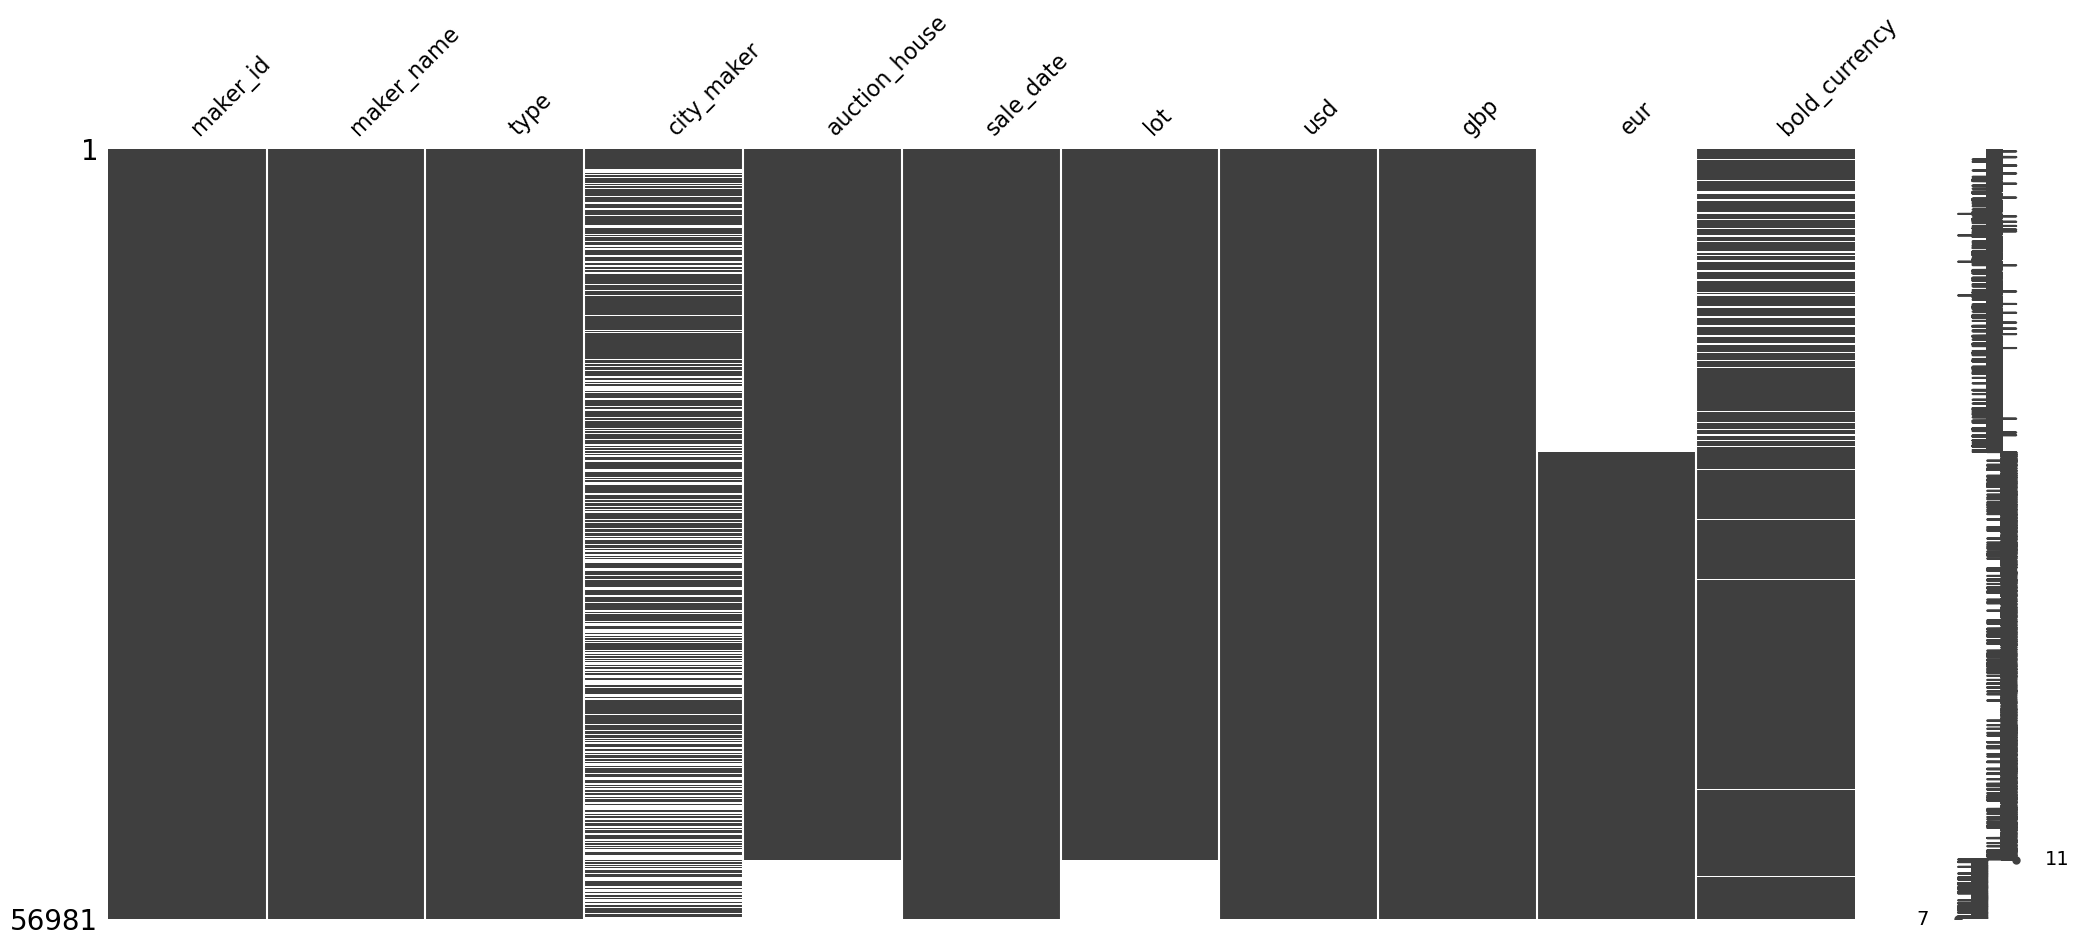

In [ ]:
msno.matrix(sales)
plt.show()
# basically euro is missing if and only if the sale is old enough (until the 1990s, at the moment of the official existence of the euro). 
# auction_house is missing if and only if the sale is recent ; bold currency almost always there recently ; no obvious pattern for city_maker and bold_currency


In [85]:
sales[sales.eur.isna()]
# last time euro was na is december 1998.

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
43794,636,"Rugeri, Francesco",Cello,Cremona,Sotheby's,1829-05-03,-,357.0,70.0,NaN,gbp
43083,623,"Rogeri, Giovanni Battista",Cello,Brescia,Puttick & Simpson,1850-11-28,-,368.0,72.0,NaN,gbp
48189,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,588.0,115.0,NaN,gbp
48190,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,715.0,140.0,NaN,gbp
48188,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1853-05-28,-,606.0,110.0,NaN,gbp
...,...,...,...,...,...,...,...,...,...,...,...
34999,10093,"Mougenot, Léon Victor",Violin,NaN,Phillip's,1998-12-10,39,2109.0,1265.0,NaN,gbp
33795,893,"Moritz, Alfred",Violin,NaN,Phillip's,1998-12-10,52,728.0,437.0,NaN,gbp
56608,971,"Wolff, Brothers",Violin,NaN,Phillip's,1998-12-10,194,575.0,345.0,NaN,gbp
47421,1356,"Smith, John",Violin,Falkirk,Phillip's,1998-12-10,35,1629.0,977.0,NaN,gbp


Cardinality of categorical values

In [91]:
sales[['maker_name','maker_id','type','city_maker','auction_house']].nunique()

maker_name       3649
maker_id         3655
type               14
city_maker        732
auction_house      40
dtype: int64

There seems to be distinct makers who have the same name, which would not be entirely surprising.

In [ ]:
# On compte le nombre d'IDs uniques par nom de fabricant
maker_counts = sales.groupby('maker_name')['maker_id'].nunique()

# On filtre ceux qui ont plus de 1 ID
multi_id_makers = maker_counts[maker_counts > 1].index.tolist()
print(f"Number of makers with multiple IDs: {len(multi_id_makers)}")
print("Namely:", multi_id_makers[:5])

sales[sales.maker_name.isin(multi_id_makers)]

Number of makers with multiple IDs: 4
Exemples : ['Kennedy, Alexander', 'Meisel, Friedrich August', 'Smith, Thomas', 'Smith, William']


,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
47475,694,"Smith, Thomas",Violin,London,Sotheby's,1983-04-07,626,1125.0,748.0,NaN,gbp
26648,15234,"Kennedy, Alexander",Violin,NaN,Phillip's,1984-08-23,55,693.0,528.0,NaN,gbp
32734,9716,"Meisel, Friedrich August",Violin,Klingenthal,Bongartz's,1984-11-26,119,467.0,389.0,NaN,NaN
47474,694,"Smith, Thomas",Violin,London,Sotheby's,1985-04-03,571,736.0,605.0,NaN,gbp
32733,9716,"Meisel, Friedrich August",Violin,Markneukirchen,Bongartz's,1985-04-22,286,401.0,314.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
32731,15325,"Meisel, Friedrich August",Violin,Klingenthal,Tarisio,2019-03-18,133,5164.0,3900.0,4552.0,gbp
47430,694,"Smith, Thomas",Cello,London,Brompton's,2019-10-21,104,20270.0,15600.0,18170.0,gbp
47483,13085,"Smith, William",Cello,Stockport,NaN,2023-06-05,NaN,7429.0,6000.0,6952.0,gbp
32732,9716,"Meisel, Friedrich August",Violin,Klingenthal,NaN,2023-06-13,NaN,2979.0,2367.0,2760.0,eur


The Thomas Smith of Lakewood, OH and the one of London might be genuinely different - it's one of the most frequent names in the western world. Similarly the four William Smith. A quick look at the Tarisio Website shows that the two Friedrich August Meisel have different dates.

In [101]:
mapping_ids = sales.groupby('maker_name')['maker_id'].unique().reset_index()

mapping_ids['nb_ids'] = mapping_ids['maker_id'].apply(len)

doublons_ids = mapping_ids[mapping_ids['nb_ids'] > 1].sort_values(by='nb_ids', ascending=False)

display(doublons_ids)

,maker_name,maker_id,nb_ids
3083,"Smith, William","[13089, 15282, 13086, 13085]",4
1722,"Kennedy, Alexander","[15234, 2962]",2
2145,"Meisel, Friedrich August","[9716, 15325]",2
3082,"Smith, Thomas","[694, 13081]",2


In [88]:
import seaborn as sns

C:\Users\Pierre\AppData\Local\Temp\ipykernel_20616\836503132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


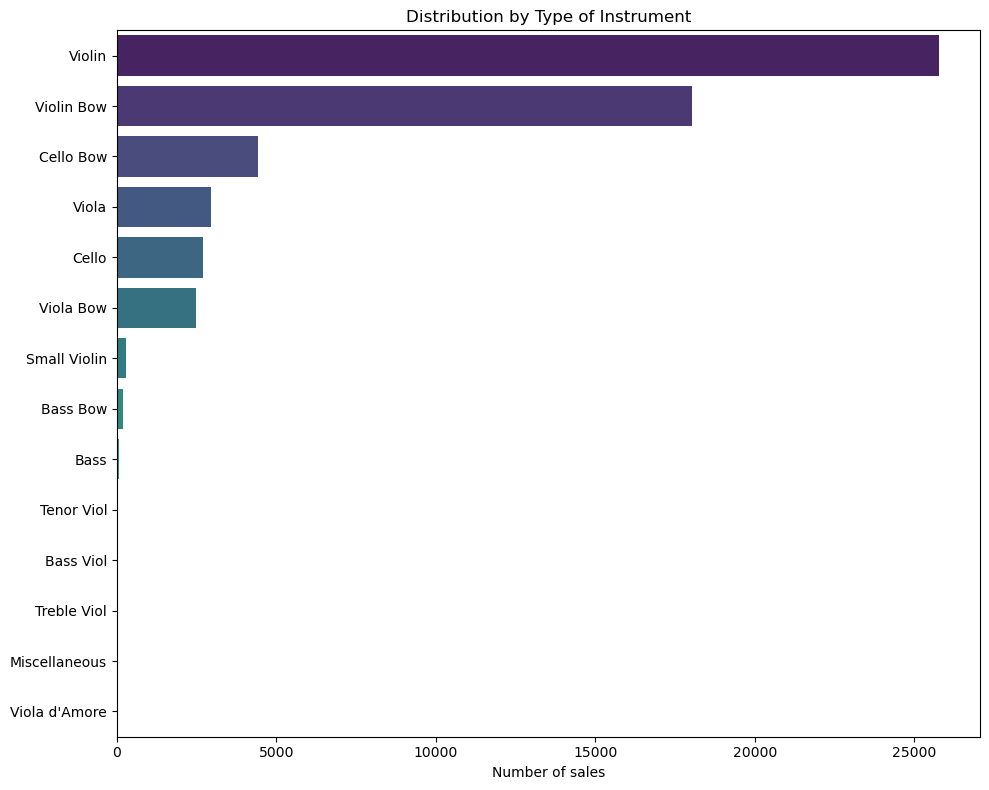

In [90]:
plt.figure(figsize=(10, 8)) 
sns.countplot(
    data=sales, 
    y='type', 
    order=sales['type'].value_counts().index,
    palette='viridis'
)

plt.title("Distribution by Type of Instrument")
plt.xlabel("Number of sales")
plt.ylabel("") 
plt.tight_layout() 
plt.show()

In [57]:
sales['usd'].describe()

count    5.697700e+04
mean     1.498615e+04
std      1.235065e+05
min      2.000000e+01
25%      1.544000e+03
50%      3.604000e+03
75%      9.352000e+03
max      1.582128e+07
Name: usd, dtype: float64

The mean is four times the median - a sign of a huge kurtosis. The distribution of prices is actually so right skewed that we cannot see anything on a histogram or distplot. We'll have to take the logarithm.

In [17]:
sales.city_maker.value_counts()

city_maker
Paris             7537
London            5471
Mirecourt         4106
Markneukirchen    2043
Cremona           1115
                  ... 
Morecambe            1
Wallgau              1
Reading, PA          1
Gorham               1
Krems                1
Name: count, Length: 720, dtype: int64

In [3]:
maker_profiles=pd.read_csv("maker_profiles_ALL.csv")

## Creation of a feature 'last_name'

In [7]:
def last_name(name):
    return name.split(",")[0]

In [9]:
sales["maker_last_name"]=sales["maker_name"].apply(last_name)

In [ ]:
sales["maker_last_name"].value_counts()
#Hill & Sons is not really a maker's last name, many makers bearing different last names worked for it

maker_last_name
Hill & Sons    3268
Sartory        1326
Bazin          1136
Tubbs          1022
Morizot         993
               ... 
Wurmer            1
Yakoub            1
Yarrington        1
Zanier            1
Zanrè             1
Name: count, Length: 2549, dtype: int64

In [ ]:
sum(sales["maker_last_name"].value_counts()>1)
#1811 last names occur more than once in sales

1811

In [ ]:
sum(sales["maker_last_name"].value_counts()>2)
#1479 last names occur more than twice in sales

1479

In [ ]:
sum(sales["maker_last_name"].value_counts()>10)
#721 last names occur more than ten times in sales

721

In [ ]:
i=0
while (sales["maker_last_name"].value_counts().cumsum()<30000).iloc[i]:
    i+=1
i
#the 84 most popular last names represent over 30k sales (hence over the half of the total)

84

In [44]:
sales["maker_name"].value_counts()

maker_name
Hill & Sons, W. E. Firm          3268
Sartory, Eugène Nicolas          1326
Tubbs, James                      936
Nürnberger, Albert                723
Thibouville-Lamy, Jérôme Firm     689
                                 ... 
Zanti, Alessandro                   1
Zapelli, Francesco                  1
Zapf, Walter                        1
Zeswitz, William H.                 1
Zucker, Frantisek                   1
Name: count, Length: 3649, dtype: int64

In [46]:
maker_profiles["maker_last_name"]=maker_profiles["maker_name"].apply(last_name)

In [ ]:
maker_profiles["maker_last_name"].value_counts()
#17 different makers were called Gagliano, a proper dynasty of makers.

maker_last_name
Gagliano        17
Hornsteiner     16
Schmidt         15
Pfretzschner    15
Klotz           14
                ..
Zari             1
Allan            1
Allard           1
Alleaume         1
Allen            1
Name: count, Length: 3397, dtype: int64

In [ ]:
sum(maker_profiles["maker_last_name"].value_counts()>10)
#10 last names had at least 10 makers with that last name

10

The sale_date feature

<Axes: >

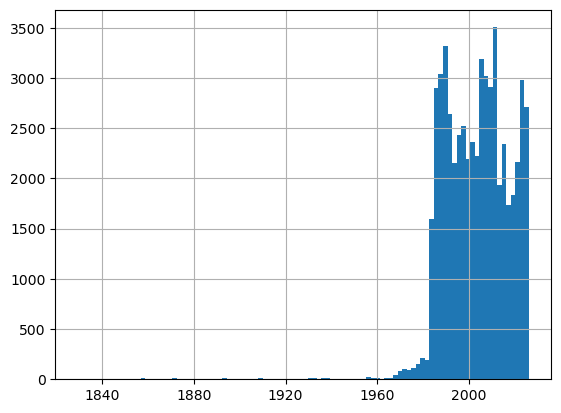

In [108]:
sales.sale_date.hist(bins=100)
#sales year run from 1825 to 2026 but almost all sales are post 1980, perhaps we should stick to that

<Axes: >

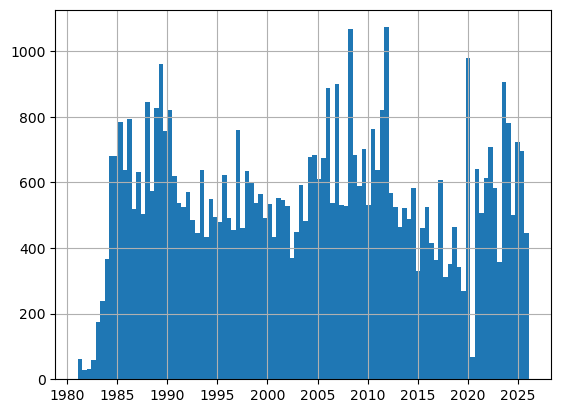

In [110]:
sales[sales.sale_date.dt.year>1980].sale_date.hist(bins=100)


Since 1984, the frequency of sales seem more or less homogenous (apart for covid in 2020)

In [107]:
(sales.sale_date.dt.year>1980).mean()
#98% of sales are post 1980

np.float64(0.9807297425367241)

In [140]:
mask_recent=sales.year>1985
sales_recent=sales[mask_recent]

In [125]:
sales[mask_recent]['usd'].describe()

count    5.213000e+04
mean     1.575455e+04
std      1.289108e+05
min      2.400000e+01
25%      1.711000e+03
50%      3.872000e+03
75%      9.737000e+03
max      1.582128e+07
Name: usd, dtype: float64

## The price feature(s) - The target

Given the kurtosis, we'll take the log of the price.

In [12]:
sales['log_usd']=sales.usd.apply(np.log)

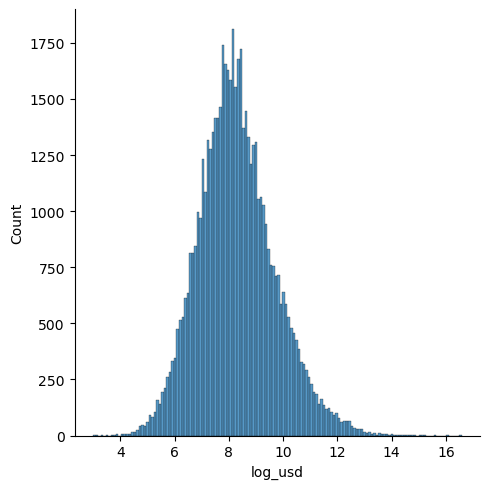

In [113]:
sns.displot(data=sales,x="log_usd")
#still a little right-skewed, but fairly normally distributed

## The 'type' feature

<Axes: xlabel='log_usd'>

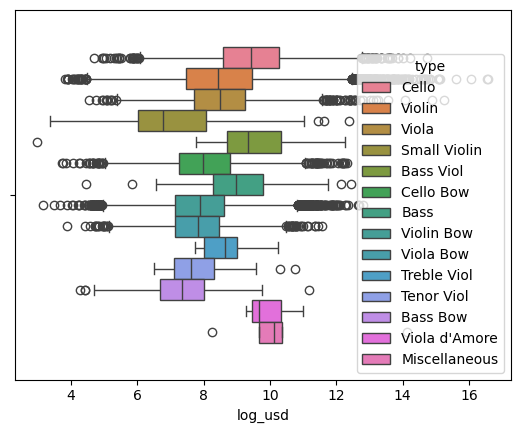

In [114]:
sns.boxplot(data=sales,x='log_usd',hue='type')

<Axes: xlabel='log_usd'>

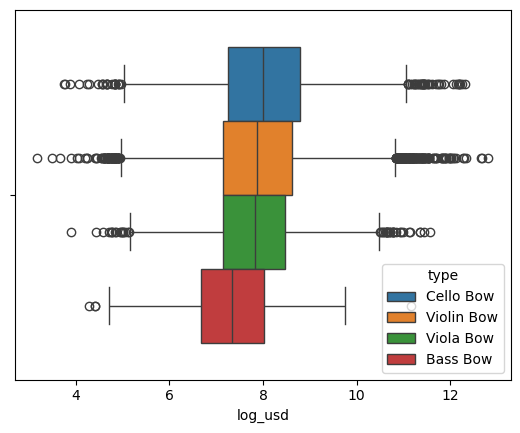

In [117]:
data_bow=sales[sales.type.str.contains('Bow')]
sns.boxplot(data=data_bow,x='log_usd',hue='type')
# different types have similar price distributions

Looks like the four types of bows have similar price distributions. Bass bows tend to be cheaper but there are much fewer occurrences of them.

## Impact of the maker on the price

We want to visualise the distribution of prices by maker. We use Ridgeplot and display the top 10 and the bottom 10 of the makers with at least 50 sales in the data base.

In [29]:
counts = sales['maker_name'].value_counts()
makers_50 = counts[counts >= 50].index

medians_50 = sales[sales['maker_name'].isin(makers_50)].groupby('maker_name')['log_usd'].median().sort_values(ascending=False)

top_10 = medians_50.head(10).index.tolist()
bottom_10 = medians_50.tail(10).index.tolist()

selection_makers = top_10 + bottom_10
df_extremes = sales[sales['maker_name'].isin(selection_makers)].copy()

df_extremes['maker_name'] = pd.Categorical(df_extremes['maker_name'], categories=selection_makers, ordered=True)

In [4]:
pip install joypy

Note: you may need to restart the kernel to use updated packages.


Note that joypy does not seem to work in the erdös ds environment so I used a normal python here.

c:\Users\Pierre\anaconda3\Lib\site-packages\joypy\joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


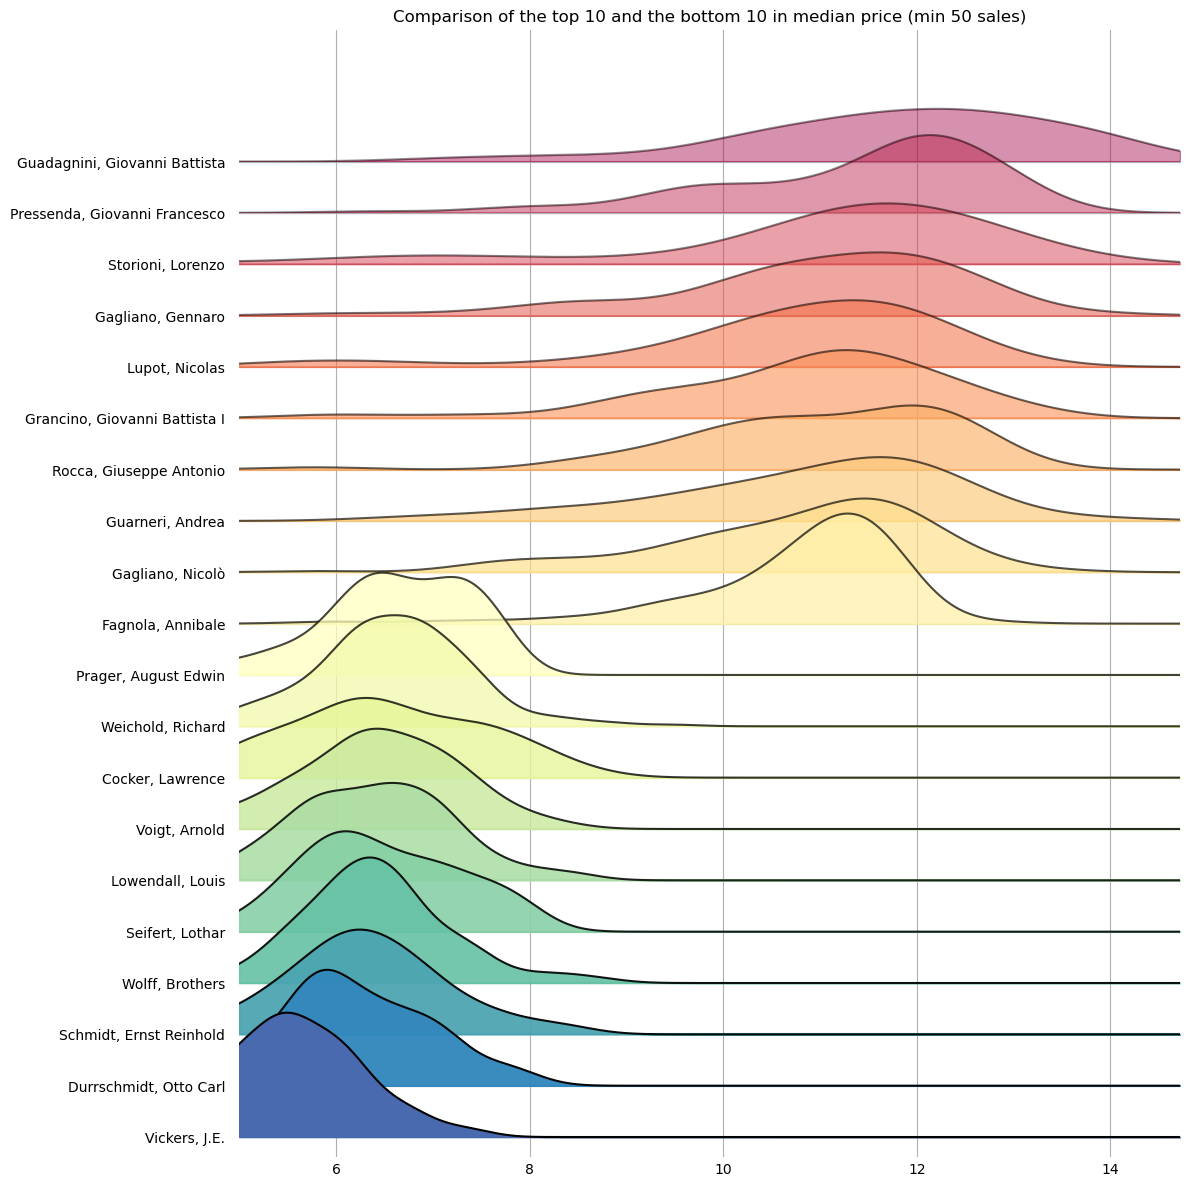

In [30]:
import joypy
from matplotlib import cm

fig, axes = joypy.joyplot(
    data=df_extremes,
    by='maker_name',
    column='log_usd',
    labels=selection_makers,
    colormap=cm.Spectral, # Spectral est top pour montrer les extrêmes (Rouge vs Bleu)
    fade=True,
    x_range=(5, df_extremes['log_usd'].max()), 
    figsize=(12, 12),
    title="Comparison of the top 10 and the bottom 10 in median price (min 50 sales)",
    overlap=1.5,
    grid=True
)



plt.show()

The top 10 is clearly italian.
Note that Antonio Stradivari, perhaps the best known liuterio, is not in the top 10. 

In [43]:
sales.groupby('maker_name')['log_usd'].describe().loc['Stradivari, Antonio']

count    192.000000
mean      10.563426
std        2.735904
min        4.700480
25%        7.956263
50%       10.645209
75%       12.672898
max       16.576867
Name: Stradivari, Antonio, dtype: float64

## Evolution of prices with time

<Axes: xlabel='sale_date', ylabel='log_usd'>

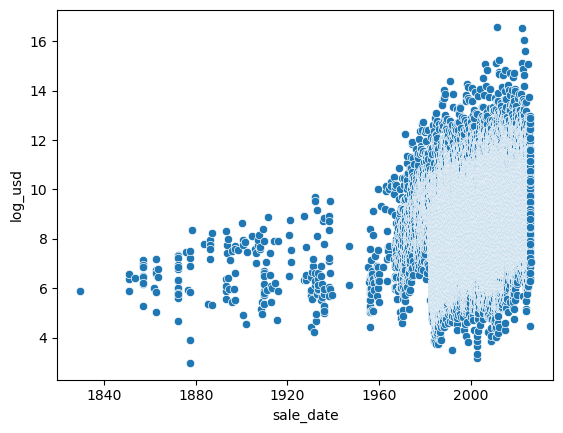

In [118]:
sns.scatterplot(data=sales,x='sale_date',y='log_usd')

We do observe some inflation across the years, but it is much more visible at the upper limit of the hull than the lower.

In [126]:
sales_recent['year']=sales.sale_date.dt.year

In [128]:
def decade(year):
    a=(year-1986) // 10
    return f"{1986+10*a}-{1986+10*a+9}"

In [141]:
sales_recent=sales_recent[sales_recent["year"]<2026]
sales_recent["decade"]=sales_recent["year"].apply(decade)

In [143]:
sales_recent.groupby('decade')['log_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
decade,,,,,,,,
1986-1995,13766.0,7.784879,1.306811,3.496508,6.887808,7.642524,8.518293,14.389642
1996-2005,12645.0,8.219501,1.297456,3.178054,7.337588,8.095599,8.956995,14.524531
2006-2015,14005.0,8.562824,1.379879,3.871201,7.656810,8.411833,9.367344,16.576867
2016-2025,11713.0,9.019678,1.217599,4.488636,8.188689,8.865029,9.729134,16.545974


There the general increase of price is visible, and regular.

## Currencies and bold_currency

These 4 sales have actually no price whatsoever mentioned and all come from the auction_house Bongartz. A quick look at the website seems to indicate the fault comes from there and is not an artefact of scraping.

In [204]:
sales.bold_currency.value_counts()

bold_currency
gbp    31786
usd    16003
eur     5330
Name: count, dtype: int64

## auction_house feature

In [227]:
sales.auction_house.value_counts()

auction_house
Tarisio                                  12441
Sotheby's                                11038
Phillip's                                 6386
Christie's                                4875
Skinner                                   4086
Bonhams                                   3436
Bongartz's                                3282
Vichy-Enchères                            2062
Brompton's                                1705
Ingles & Hayday                           1419
Sotheby Parke Bernet                       283
Millon & Associés (Gilles Chancereul)      274
Puttick & Simpson                          208
Dorotheum                                  207
Guy Laurent                                174
Gardiner-Houlgate                          162
T2 Auctions                                153
Ader Tajan                                 139
da Salo Auction                            131
Tajan                                       73
Butterfield & Butterfield                   70

40 different auction houses appear, of which 9 appear a single time. The Tarisio house is obviously the most frequent. 19 of them appear more than 100 times. Sotheby Parke Bernet and Sotheby's are the two names of the same auction house at different points in time.

In [31]:
rare_houses= sales.auction_house.value_counts().index[-21:]

In [32]:
def house2(house):
    return 'Rare' if house in rare_houses else house

In [33]:
house2('Tajan'),house2('Tarisio')

('Rare', 'Tarisio')

In [34]:
sales['house2']=sales['auction_house'].apply(house2)

In [36]:
sales['house2']=sales['auction_house'].apply(house2)

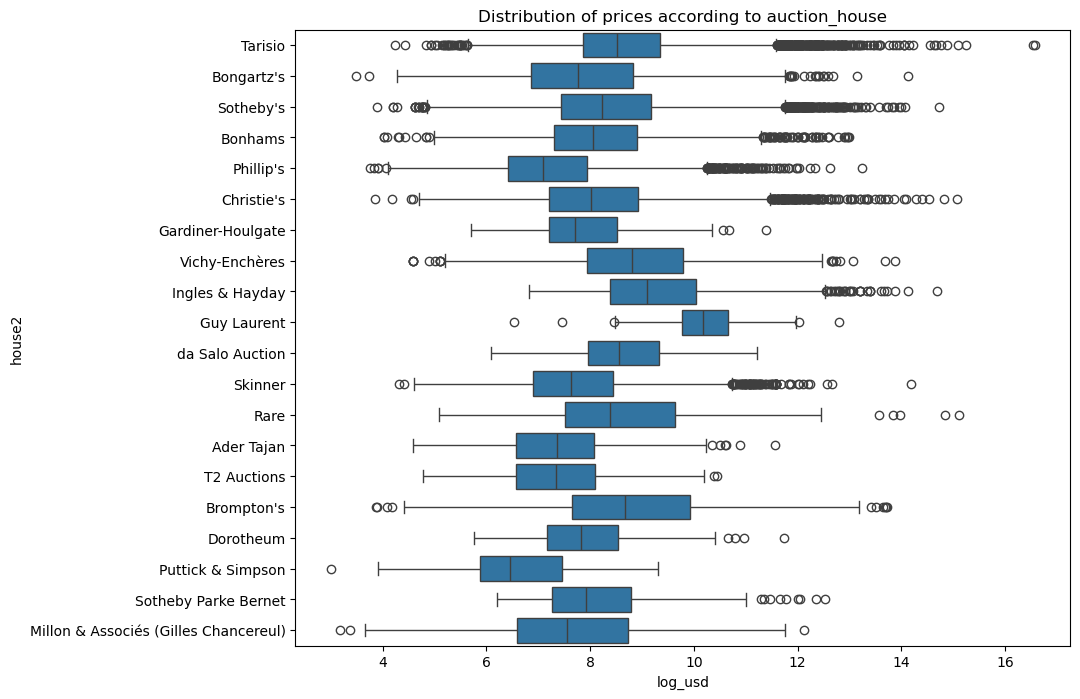

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# On définit la taille de la figure pour que ce soit lisible
plt.figure(figsize=(10, 8))

# On passe 'house2' en paramètre 'y' au lieu de 'hue'
sns.boxplot(data=sales, x='log_usd', y='house2')

plt.title('Distribution of prices according to auction_house')
plt.show()

One big house achieved incredible results, Guy Laurent. Skinner has a particularly heavy tail. The most represented houses - the highest on the graph - did not necessarily make the best results.

<Axes: >

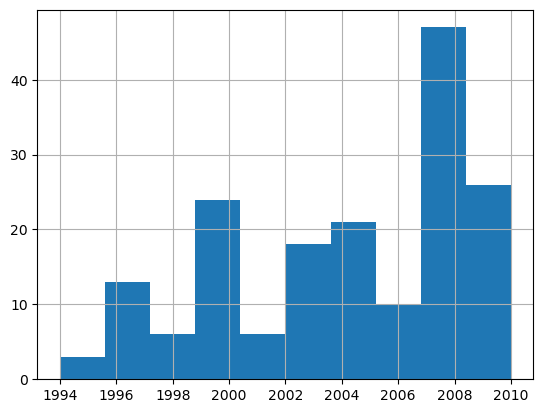

In [276]:
sales[sales['house2']=='Guy Laurent']['year'].hist()

Guy Laurent has 174 sales archived here, some of them feature particularly famous makers such as Jean Adam. it seems that it made sales from 1994 to 2010. In particular it didn't sell the last 15 years, where prices increased significantly, which makes the sensational prices particularly remarkable.

In [282]:
most_frequent_makers=sales['maker_name'].value_counts().index[:30]

In [285]:
def maker2(maker):
    return maker if maker in most_frequent_makers else 'Rare'

In [286]:
sales['maker2']=sales['maker_name'].apply(maker2)

In [302]:
sales_moder['maker2']=sales_moder['maker_name'].apply(maker2)

The graphic above shows that certain frequently sold makers tend to achieve better prices than average (among the recent, moderate sale, otherwise graphic illegible). One particularly valued maker is Dominique Peccatte. We also see that all the 30 most frequently sold makers, apart from Hill & Sons Firm (which again is not an individual maker but a firm), George Craske and three german makers, have French names. 

It is worth noting that four families have two frequently sold makers : Bazin, Lamy, Vigneron and Ouchard, with a father and a son. The Ouchard son is somehow much more valued on the market, showing that two members of a family can be very differently valued. Many of the most prolific makers do not show a better distribution, than distribution of the "rare" category.

In [298]:
salesAdam=sales_moder[sales_moder['maker_last_name']=='Adam']

<Axes: xlabel='usd'>

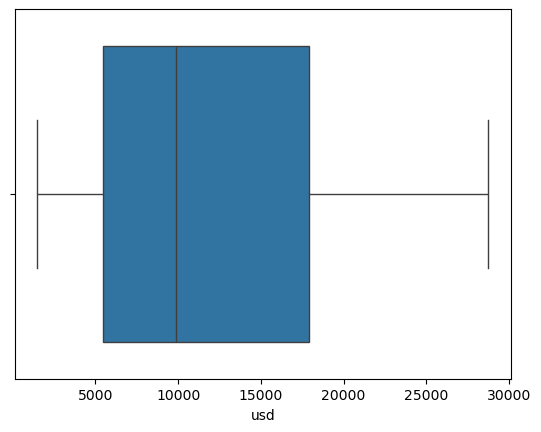

In [299]:
sns.boxplot(data=salesAdam,x='usd')

<Axes: xlabel='usd'>

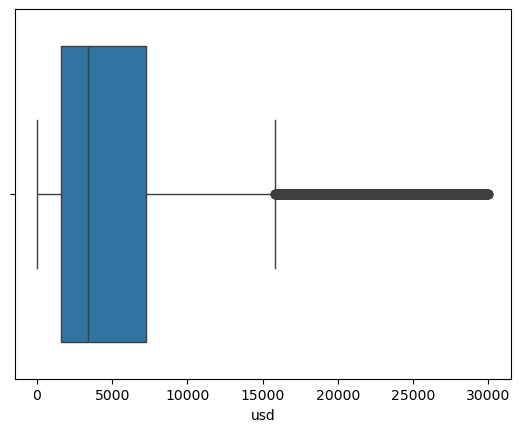

In [297]:
sns.boxplot(data=sales_moder,x='usd')

Certain makers that do not belong to the 30 most frequently sold ones, such as those of the Adam family, perform much better than average.

## Dates of makers

In [307]:
sum(maker_profiles.date.isna())

1499

1500 out 5000 maker_profiles have no dates, which is a problem in a bid to exploit the era a maker lives in to evaluate his work.

Let's have a look at these makers which have no date.

In [322]:
maker_profiles[maker_profiles['date'].isna()]

,maker_name,maker_id,role,date,info,maker_last_name
16,"Aerts, René & Marcel",15467,Violin maker,NaN,NaN,Aerts
18,"Aguzzi, Dario",15601,Violin maker,NaN,NaN,Aguzzi
30,"Albani, Michele",1676,Violin maker,NaN,NaN,Albani
33,"Alberini, Guido",15592,Violin maker,NaN,NaN,Alberini
34,"Albert, Ádám Karóly",15279,Violin maker,NaN,NaN,Albert
...,...,...,...,...,...,...
4935,"Zobboli, Bruno",840,Violin maker,NaN,NaN,Zobboli
4937,"Zoephel, Willy",3072,Violin maker,NaN,NaN,Zoephel
4941,"Zucker, Frantisek",15411,–,NaN,NaN,Zucker
4945,"Zurlini, Nicola",842,Violin maker,NaN,NaN,Zurlini


Those with no date all seem to have no info. And it is not an artefact of the scraping, the website genuinely gives no info about them.

In [319]:
ids_a_filtrer = maker_profiles.loc[maker_profiles['date'].isna(), 'maker_id'].unique()
sales_filtres = sales[sales['maker_id'].isin(ids_a_filtrer)]

In [326]:
sales_filtres.usd.describe()

count      6434.000000
mean       3383.281318
std        4966.797735
min          48.000000
25%         903.500000
50%        1955.000000
75%        4027.250000
max      171524.000000
Name: usd, dtype: float64

These makers, which represent almost one third of the makers' list, represent less than one eigth of the sales. But that's not quite negligible. Also they tend to sell significantly lower prices than the others.

In [327]:
sales.usd.describe()

count    5.716500e+04
mean     1.516633e+04
std      1.233990e+05
min      2.000000e+01
25%      1.548000e+03
50%      3.637000e+03
75%      9.442000e+03
max      1.582128e+07
Name: usd, dtype: float64

In [370]:
import re

def birth_cent(date_str):
    # On gère le cas où la date est nulle ou non définie
    if not isinstance(date_str, str) or date_str.lower() == 'nan':
        return np.nan
    
    # On cherche le premier groupe de 3 ou 4 chiffres (ex: 1750, 850)
    match = re.search(r'\d{3,4}', date_str)
    
    if match:
        annee = int(match.group())
        
        # Calcul du siècle : 1750 // 100 = 17 -> 17 + 1 = 18e siècle
        # Exception pour les années pile comme 1700 qui sont encore au XVIIe
        if annee % 100 == 0:
            siecle_num = annee // 100
        else:
            siecle_num = (annee // 100) + 1
            
        return str(siecle_num)
    
    return np.nan



In [371]:
maker_profiles['birth_cent']=maker_profiles['date'].apply(birth_cent)

In [372]:
maker_profiles['birth_cent'].value_counts()

birth_cent
19    1640
18     811
20     772
17     201
16      22
21       3
2        1
15       1
Name: count, dtype: int64

In [376]:
maker_profiles[maker_profiles['birth_cent']=='2']
#that's clearly a mistake, we'll make the century XVIIIth.

,maker_name,role,date,info,maker_last_name,birth_cent
maker_id,,,,,,
6205,"Ficker, Johann Gottlob II",Violin maker,178-1827,Johann Gottlob Ficker was the son and pupil of...,Ficker,2


In [379]:
maker_profiles.loc[maker_profiles['birth_cent']=='2','birth_cent']='18'


In [380]:
maker_profiles['birth_cent'].value_counts()

birth_cent
19    1640
18     812
20     772
17     201
16      22
21       3
15       1
Name: count, dtype: int64

In [381]:
def birth_cent_from_id(maker_id):
    return birth_cent(maker_profiles.loc[maker_id,'date'])

In [382]:
sales['maker_birth_cent']=sales['maker_id'].apply(birth_cent_from_id)

In [383]:
sales_moder['maker_birth_cent']=sales_moder['maker_id'].apply(birth_cent_from_id)

There is an evidence here that older centuries are more valued than newer. It's precisely because the box plot makes a mess when maker_birth_cent is numeric that I decided to make it string. Note that the makers of the XXIst and of the XVth century are not represented, because too few.

<Axes: xlabel='usd', ylabel='maker_birth_cent'>

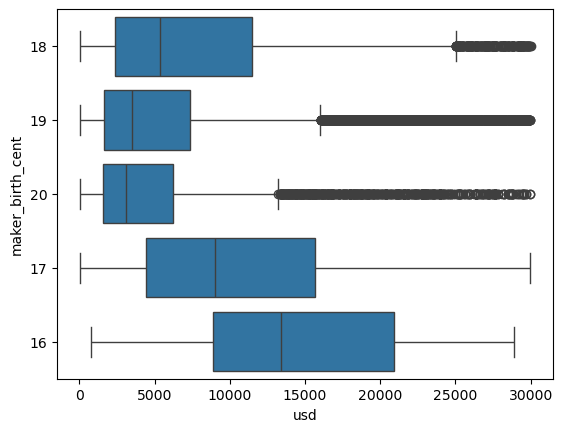

In [384]:
sns.boxplot(data=sales_moder,x='usd',y='maker_birth_cent')

In [387]:
sales_moder.to_csv("sales_moder.csv",index=False)

In [393]:
sales.to_csv("sales_engineered.csv",index=False)

In [391]:
sales_recent.to_csv("sales_recent.csv",index=False)

In [395]:
maker_profiles.to_csv("maker_profiles_engineered.csv",index=False)